# Importing Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [4]:
# Set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
plt.style.use('fivethirtyeight')

# Loading Data

In [ ]:
# Behaviour datasets configuration
dataset_1 = "Mask Wearing.csv"
target_1 = "mask_wearing"

dataset_2 = "Hand Washing.csv"
target_2 = "wash_hands"

dataset_3 = "Avoid Crowded Areas.csv"
target_3 = "avoid_crowded_areas"

dataset_4 = "Self Isolation.csv"
target_4 = "willingness_self_isolate"

# Outcome-specific LSTM parameters
lstm_settings = {
    "mask_wearing": {
        "sequence_length": 30,
        "units": 32,
        "dropout": 0.30,
        "batch_size": 16,
        "learning_rate": 0.0005
    },
    "wash_hands": {
        "sequence_length": 7,
        "units": 16,
        "dropout": 0.20,
        "batch_size": 8,
        "learning_rate": 0.0005
    },
    "avoid_crowded_areas": {
        "sequence_length": 21,
        "units": 32,
        "dropout": 0.30,
        "batch_size": 16,
        "learning_rate": 0.0005
    },
    "willingness_self_isolate": {
        "sequence_length": 7,
        "units": 16,
        "dropout": 0.20,
        "batch_size": 8,
        "learning_rate": 0.0005
    }
}

In [6]:
# Load and prepare data
def load_and_prepare_lstm_data(dataset, target):
    """
    Loads the final behaviour dataset and prepares daily-level
    multivariate time-series data for LSTM modelling.
    """

    df = pd.read_csv(dataset)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values("date")

    exog_vars = [
        # Perception variables
        "covid_dangerous_for_me",
        "likely_to_get_covid",
        "trust_in_government_handling",
        "important_to_improve_health",
        "life_affected_by_covid",

        # Policy variables
        "mask_policy",
        "gathering_restriction",
        "cancel_public_events",
        "stay_home_requirement",
        "public_information_campaign",
        "testing_policy",
        "contact_tracing",
        "stringency_index",

        # Epidemiological variables
        "new_cases_smoothed",
        "new_deaths_smoothed",
        "reproduction_rate",
        "hospital_patients",
        "people_fully_vaccinated_per_hundred",

        # Date features
        "year",
        "month",
        "days_since_start",
        "week_index",

        # Lag features
        "new_cases_smoothed_lag7",
        "new_cases_smoothed_lag14",
        "new_deaths_smoothed_lag7",
        "new_deaths_smoothed_lag14",
        "reproduction_rate_lag7",
        "reproduction_rate_lag14",
        "hospital_patients_lag7",
        "hospital_patients_lag14",
        "people_fully_vaccinated_per_hundred_lag7",
        "people_fully_vaccinated_per_hundred_lag14",
        "stringency_index_lag7",
        "stringency_index_lag14",
        "mask_policy_lag7",
        "mask_policy_lag14",
        "stay_home_requirement_lag7",
        "stay_home_requirement_lag14",
        "gathering_restriction_lag7",
        "gathering_restriction_lag14",
        "cancel_public_events_lag7",
        "cancel_public_events_lag14",

        # Interaction variables
        "policy_x_cases",
        "risk_x_trust"
    ]

    exog_vars = [
        col for col in exog_vars
        if col in df.columns
    ]

    daily_df = (
        df.groupby("date")[[target] + exog_vars]
        .mean()
        .reset_index()
    )

    daily_df = daily_df.set_index("date")

    daily_df = daily_df.asfreq("D")

    daily_df = daily_df.ffill().bfill()

    print("Dataset loaded successfully")
    print("Daily LSTM dataset shape:", daily_df.shape)
    print("Target variable:", target)
    print("Number of exogenous variables:", len(exog_vars))

    return daily_df, exog_vars

# LSTM Model

In [ ]:
# Create LSTM sequences
def create_lstm_sequences(
    target_history_scaled,
    exog_scaled,
    target_scaled,
    sequence_length
):
    """
    Creates two LSTM inputs:
    1. Historical sequences containing previous target values and
       previous exogenous variables.
    2. Current-day exogenous variables for the day being predicted.

    The output is the target value for the current day.
    """

    X_sequence = []
    X_current = []
    y = []

    historical_features = np.column_stack([
        target_history_scaled,
        exog_scaled
    ])

    for i in range(sequence_length, len(historical_features)):
        X_sequence.append(
            historical_features[i-sequence_length:i, :]
        )

        X_current.append(
            exog_scaled[i, :]
        )

        y.append(
            target_scaled[i, 0]
        )

    return (
        np.asarray(X_sequence),
        np.asarray(X_current),
        np.asarray(y)
    )

In [ ]:
# Train-validation-test split and scaling
def prepare_lstm_data(
    daily_df,
    target,
    exog_vars,
    sequence_length,
    train_ratio=0.70,
    validation_ratio=0.15
):
    """
    Creates chronological training, validation and testing sets.

    Separate scalers are used for the exogenous variables and target.
    Both scalers are fitted only on the training period.
    """

    X_df = daily_df[exog_vars].copy()
    y_df = daily_df[[target]].copy()

    total_size = len(daily_df)
    train_end = int(total_size * train_ratio)
    validation_end = int(
        total_size * (train_ratio + validation_ratio)
    )

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_scaler.fit(X_df.iloc[:train_end])
    y_scaler.fit(y_df.iloc[:train_end])

    X_scaled = X_scaler.transform(X_df)
    y_scaled = y_scaler.transform(y_df)

    (
        X_sequence_all,
        X_current_all,
        y_all
    ) = create_lstm_sequences(
        target_history_scaled=y_scaled,
        exog_scaled=X_scaled,
        target_scaled=y_scaled,
        sequence_length=sequence_length
    )

    sequence_dates = daily_df.index[sequence_length:]

    train_sequence_end = train_end - sequence_length
    validation_sequence_end = validation_end - sequence_length

    X_sequence_train = X_sequence_all[:train_sequence_end]
    X_current_train = X_current_all[:train_sequence_end]
    y_train = y_all[:train_sequence_end]

    X_sequence_validation = X_sequence_all[
        train_sequence_end:validation_sequence_end
    ]
    X_current_validation = X_current_all[
        train_sequence_end:validation_sequence_end
    ]
    y_validation = y_all[
        train_sequence_end:validation_sequence_end
    ]

    X_sequence_test = X_sequence_all[
        validation_sequence_end:
    ]
    X_current_test = X_current_all[
        validation_sequence_end:
    ]
    y_test = y_all[
        validation_sequence_end:
    ]

    validation_dates = sequence_dates[
        train_sequence_end:validation_sequence_end
    ]
    test_dates = sequence_dates[
        validation_sequence_end:
    ]

    print("Chronological Split")
    print("Sequence length:", sequence_length)
    print("Historical features:", X_sequence_train.shape[2])
    print("Current-day exogenous features:", X_current_train.shape[1])
    print("X_sequence_train shape:", X_sequence_train.shape)
    print("X_sequence_validation shape:", X_sequence_validation.shape)
    print("X_sequence_test shape:", X_sequence_test.shape)

    return (
        X_sequence_train,
        X_current_train,
        y_train,
        X_sequence_validation,
        X_current_validation,
        y_validation,
        X_sequence_test,
        X_current_test,
        y_test,
        X_scaler,
        y_scaler,
        validation_dates,
        test_dates,
        train_end,
        validation_end
    )


# Prepare final training and testing data
def prepare_final_lstm_data(
    daily_df,
    target,
    exog_vars,
    sequence_length,
    training_end
):
    """
    Refits both scalers using the combined training and validation
    period and prepares the untouched final test period.
    """

    X_df = daily_df[exog_vars].copy()
    y_df = daily_df[[target]].copy()

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_scaler.fit(X_df.iloc[:training_end])
    y_scaler.fit(y_df.iloc[:training_end])

    X_scaled = X_scaler.transform(X_df)
    y_scaled = y_scaler.transform(y_df)

    (
        X_sequence_all,
        X_current_all,
        y_all
    ) = create_lstm_sequences(
        target_history_scaled=y_scaled,
        exog_scaled=X_scaled,
        target_scaled=y_scaled,
        sequence_length=sequence_length
    )

    sequence_dates = daily_df.index[sequence_length:]
    training_sequence_end = training_end - sequence_length

    X_sequence_train = X_sequence_all[:training_sequence_end]
    X_current_train = X_current_all[:training_sequence_end]
    y_train = y_all[:training_sequence_end]

    X_sequence_test = X_sequence_all[training_sequence_end:]
    X_current_test = X_current_all[training_sequence_end:]
    y_test = y_all[training_sequence_end:]

    test_dates = sequence_dates[training_sequence_end:]

    return (
        X_sequence_train,
        X_current_train,
        y_train,
        X_sequence_test,
        X_current_test,
        y_test,
        X_scaler,
        y_scaler,
        test_dates
    )

In [ ]:
# Build LSTM model
def build_lstm_model(
    sequence_input_shape,
    current_input_shape,
    units,
    dropout_rate,
    learning_rate
):
    """
    Builds a two-input LSTM model.

    The LSTM processes the historical target and exogenous sequence,
    while the second input provides current-day exogenous conditions.
    """

    sequence_input = Input(
        shape=sequence_input_shape,
        name="historical_sequence"
    )

    current_input = Input(
        shape=current_input_shape,
        name="current_exogenous"
    )

    sequence_output = LSTM(
        units=units,
        return_sequences=False
    )(sequence_input)

    sequence_output = Dropout(
        dropout_rate
    )(sequence_output)

    combined = Concatenate()([
        sequence_output,
        current_input
    ])

    combined = Dense(
        16,
        activation="relu"
    )(combined)

    output = Dense(1)(combined)

    model = Model(
        inputs=[sequence_input, current_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss="mse"
    )

    return model

In [ ]:
# Inverse transform target
def inverse_transform_target(values, y_scaler):
    """
    Converts scaled target values back to their original scale.
    """

    values = np.asarray(values).reshape(-1, 1)
    return y_scaler.inverse_transform(values).reshape(-1)


# Evaluate model
def evaluate_lstm_model(
    y_test_actual,
    y_pred_actual,
    persistence_predictions
):
    """
    Calculates LSTM and persistence baseline accuracy metrics
    and returns them as two separate result tables.
    """

    # LSTM accuracy metrics
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mape = mean_absolute_percentage_error(
        y_test_actual,
        y_pred_actual
    )

    lstm_results = pd.DataFrame({
        "Model": ["LSTM"],
        "MSE": [mse],
        "RMSE": [rmse],
        "MAE": [mae],
        "MAPE": [mape]
    })

    # Persistence baseline accuracy metrics
    persistence_mse = mean_squared_error(
        y_test_actual,
        persistence_predictions
    )
    persistence_rmse = np.sqrt(persistence_mse)
    persistence_mae = mean_absolute_error(
        y_test_actual,
        persistence_predictions
    )
    persistence_mape = mean_absolute_percentage_error(
        y_test_actual,
        persistence_predictions
    )

    persistence_results = pd.DataFrame({
        "Model": ["Persistence Baseline"],
        "MSE": [persistence_mse],
        "RMSE": [persistence_rmse],
        "MAE": [persistence_mae],
        "MAPE": [persistence_mape]
    })

    print("LSTM Accuracy Results")
    print(lstm_results)

    print("\nPersistence Baseline Accuracy Results")
    print(persistence_results)

    return lstm_results, persistence_results

In [11]:
# Plot results
def plot_lstm_results(
    daily_df,
    target,
    train_size,
    test_dates,
    y_test_actual,
    y_pred_actual,
    persistence_predictions
):
    """
    Creates separate plots for the LSTM model and persistence baseline.
    """

    y_train_plot = daily_df[target].iloc[:train_size]
    y_axis_label = target.replace("_", " ").title()

    actual_series = pd.Series(
        y_test_actual,
        index=test_dates
    )

    predicted_series = pd.Series(
        y_pred_actual,
        index=test_dates
    )

    persistence_series = pd.Series(
        persistence_predictions,
        index=test_dates
    )


    # LSTM: Training, actual test and predicted values
    plt.figure(figsize=(14, 7))

    plt.plot(
        y_train_plot.index,
        y_train_plot,
        label="Training Data",
        color="#1f77b4",
        linewidth=2
    )

    plt.plot(
        actual_series.index,
        actual_series,
        label="Actual Test Data",
        color="#ff7f0e",
        linewidth=2
    )

    plt.plot(
        predicted_series.index,
        predicted_series,
        label="LSTM Predicted Values",
        color="#d62728",
        linewidth=2.5
    )

    plt.xlabel("Date", fontsize=14)
    plt.ylabel(y_axis_label, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Persistence: Training, actual test and baseline values
    plt.figure(figsize=(14, 7))

    plt.plot(
        y_train_plot.index,
        y_train_plot,
        label="Training Data",
        color="#1f77b4",
        linewidth=2
    )

    plt.plot(
        actual_series.index,
        actual_series,
        label="Actual Test Data",
        color="#ff7f0e",
        linewidth=2
    )

    plt.plot(
        persistence_series.index,
        persistence_series,
        label="Persistence Baseline",
        color="#d62728",
        linewidth=2
    )

    plt.xlabel("Date", fontsize=14)
    plt.ylabel(y_axis_label, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # LSTM: Actual vs predicted
    plt.figure(figsize=(7, 7))

    plt.scatter(
        actual_series,
        predicted_series,
        color="#1f77b4",
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        [actual_series.min(), actual_series.max()],
        [actual_series.min(), actual_series.max()],
        color="#d62728",
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("Actual Values", fontsize=13)
    plt.ylabel("Predicted Values", fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Persistence: Actual vs predicted
    plt.figure(figsize=(7, 7))

    plt.scatter(
        actual_series,
        persistence_series,
        color="#1f77b4",
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        [actual_series.min(), actual_series.max()],
        [actual_series.min(), actual_series.max()],
        color="#d62728",
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("Actual Values", fontsize=13)
    plt.ylabel("Predicted Values", fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # LSTM residual plot
    lstm_residuals = actual_series - predicted_series

    plt.figure(figsize=(14, 5))

    plt.plot(
        lstm_residuals.index,
        lstm_residuals,
        color="#1f77b4",
        linewidth=2
    )

    plt.axhline(
        0,
        color="#d62728",
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("Date", fontsize=13)
    plt.ylabel("Residual", fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Persistence residual plot
    persistence_residuals = actual_series - persistence_series

    plt.figure(figsize=(14, 5))

    plt.plot(
        persistence_residuals.index,
        persistence_residuals,
        color="#1f77b4",
        linewidth=2
    )

    plt.axhline(
        0,
        color="#d62728",
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("Date", fontsize=13)
    plt.ylabel("Residual", fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# LSTM pipeline
def run_lstm_pipeline(dataset, target):
    """
    Runs the complete direct-prediction LSTM pipeline using the
    outcome-specific parameters defined in lstm_settings.
    """

    np.random.seed(42)
    tf.random.set_seed(42)
    tf.keras.backend.clear_session()

    daily_df, exog_vars = load_and_prepare_lstm_data(
        dataset,
        target
    )

    settings = lstm_settings[target]

    print("Outcome-specific LSTM settings")
    print(settings)

    (
        X_sequence_train,
        X_current_train,
        y_train,
        X_sequence_validation,
        X_current_validation,
        y_validation,
        X_sequence_test_unused,
        X_current_test_unused,
        y_test_unused,
        X_scaler,
        y_scaler,
        validation_dates,
        test_dates_unused,
        train_end,
        validation_end
    ) = prepare_lstm_data(
        daily_df=daily_df,
        target=target,
        exog_vars=exog_vars,
        sequence_length=settings["sequence_length"]
    )

    model = build_lstm_model(
        sequence_input_shape=(
            X_sequence_train.shape[1],
            X_sequence_train.shape[2]
        ),
        current_input_shape=(
            X_current_train.shape[1],
        ),
        units=settings["units"],
        dropout_rate=settings["dropout"],
        learning_rate=settings["learning_rate"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        min_delta=1e-5
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )

    validation_history = model.fit(
        [X_sequence_train, X_current_train],
        y_train,
        validation_data=(
            [X_sequence_validation, X_current_validation],
            y_validation
        ),
        epochs=200,
        batch_size=settings["batch_size"],
        callbacks=[early_stop, reduce_lr],
        verbose=0,
        shuffle=False
    )

    print(
        "Validation training epochs:",
        len(validation_history.history["loss"])
    )

    # Refit the selected configuration using training + validation data
    (
        X_sequence_train_final,
        X_current_train_final,
        y_train_final,
        X_sequence_test,
        X_current_test,
        y_test,
        X_scaler_final,
        y_scaler_final,
        test_dates
    ) = prepare_final_lstm_data(
        daily_df=daily_df,
        target=target,
        exog_vars=exog_vars,
        sequence_length=settings["sequence_length"],
        training_end=validation_end
    )

    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    final_model = build_lstm_model(
        sequence_input_shape=(
            X_sequence_train_final.shape[1],
            X_sequence_train_final.shape[2]
        ),
        current_input_shape=(
            X_current_train_final.shape[1],
        ),
        units=settings["units"],
        dropout_rate=settings["dropout"],
        learning_rate=settings["learning_rate"]
    )

    final_early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        min_delta=1e-5
    )

    final_reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )

    final_history = final_model.fit(
        [X_sequence_train_final, X_current_train_final],
        y_train_final,
        validation_split=0.10,
        epochs=200,
        batch_size=settings["batch_size"],
        callbacks=[final_early_stop, final_reduce_lr],
        verbose=0,
        shuffle=False
    )

    y_pred_scaled = final_model.predict(
        [X_sequence_test, X_current_test],
        verbose=0
    )

    y_test_actual = inverse_transform_target(
        y_test,
        y_scaler_final
    )

    y_pred_raw = inverse_transform_target(
        y_pred_scaled,
        y_scaler_final
    )

    # Clip only after model fitting and raw prediction generation
    y_pred_actual = np.clip(
        y_pred_raw,
        1,
        5
    )

    persistence_predictions = (
        daily_df[target]
        .shift(1)
        .loc[test_dates]
        .to_numpy()
    )

    lstm_accuracy_results, persistence_accuracy_results = evaluate_lstm_model(
        y_test_actual,
        y_pred_actual,
        persistence_predictions
    )

    lstm_accuracy_results["Sequence Length"] = settings["sequence_length"]
    lstm_accuracy_results["LSTM Units"] = settings["units"]
    lstm_accuracy_results["Dropout"] = settings["dropout"]
    lstm_accuracy_results["Learning Rate"] = settings["learning_rate"]
    lstm_accuracy_results["Batch Size"] = settings["batch_size"]

    plot_lstm_results(
        daily_df,
        target,
        validation_end,
        test_dates,
        y_test_actual,
        y_pred_actual,
        persistence_predictions
    )

    return final_model, lstm_accuracy_results, persistence_accuracy_results, final_history

# Results


Dataset loaded successfully
Daily LSTM dataset shape: (727, 45)
Target variable: mask_wearing
Number of exogenous variables: 44
Outcome-specific LSTM settings
{'sequence_length': 30, 'units': 32, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005}
Chronological Split
Sequence length: 30
Historical features: 45
Current-day exogenous features: 44
X_sequence_train shape: (478, 30, 45)
X_sequence_validation shape: (109, 30, 45)
X_sequence_test shape: (110, 30, 45)
Validation training epochs: 16
LSTM Accuracy Results
  Model       MSE      RMSE       MAE      MAPE
0  LSTM  0.773153  0.879291  0.756127  0.197248

Persistence Baseline Accuracy Results
                  Model       MSE      RMSE       MAE      MAPE
0  Persistence Baseline  0.190834  0.436846  0.252175  0.062469


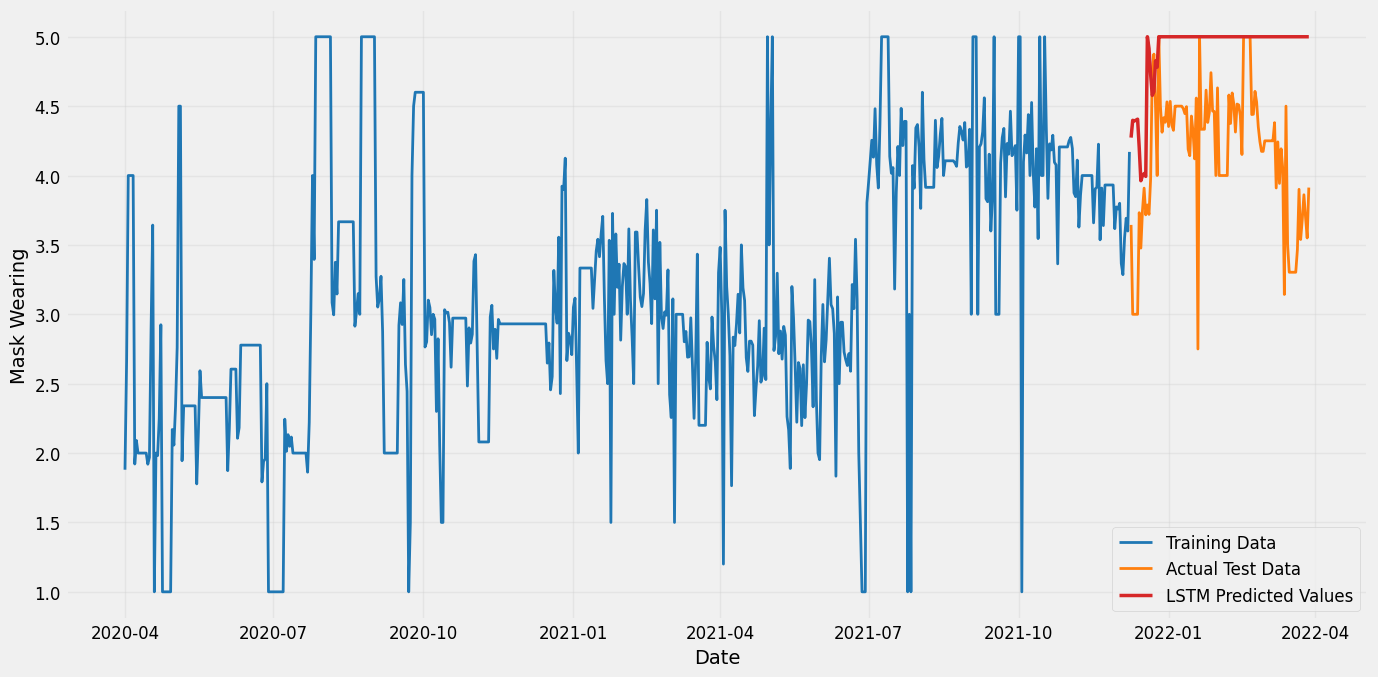

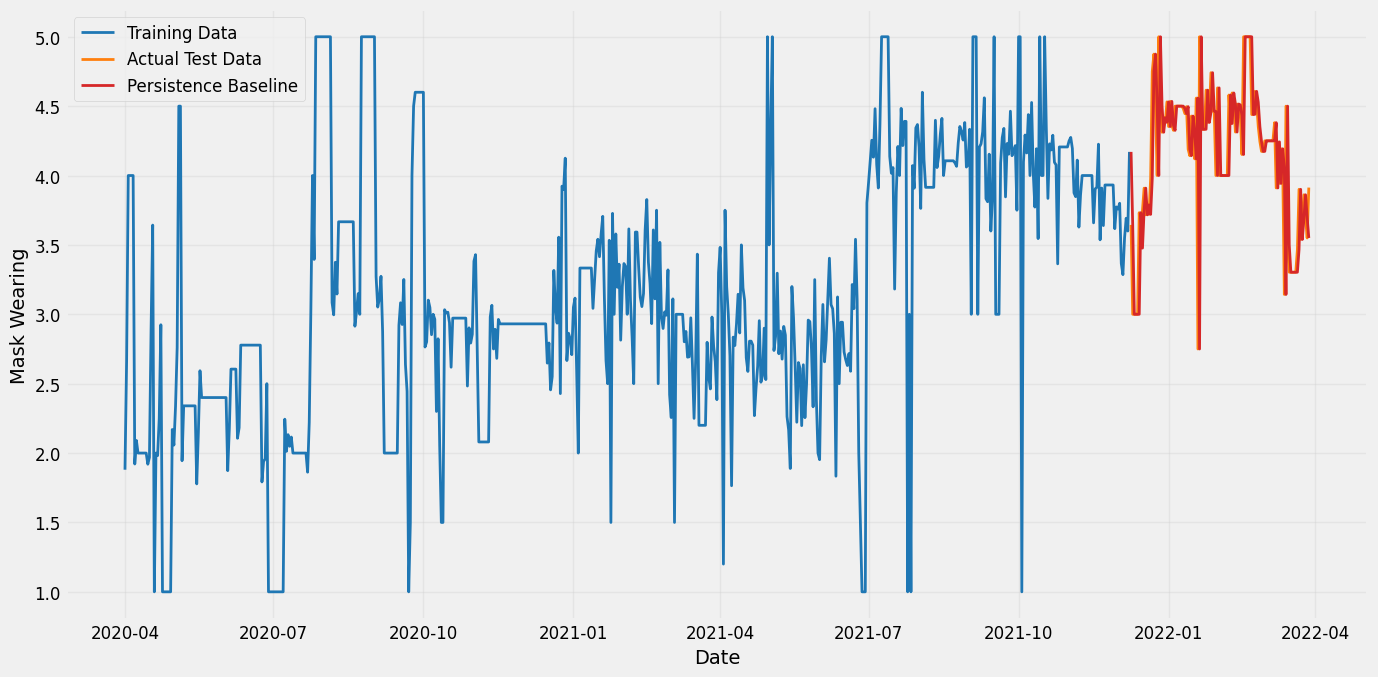

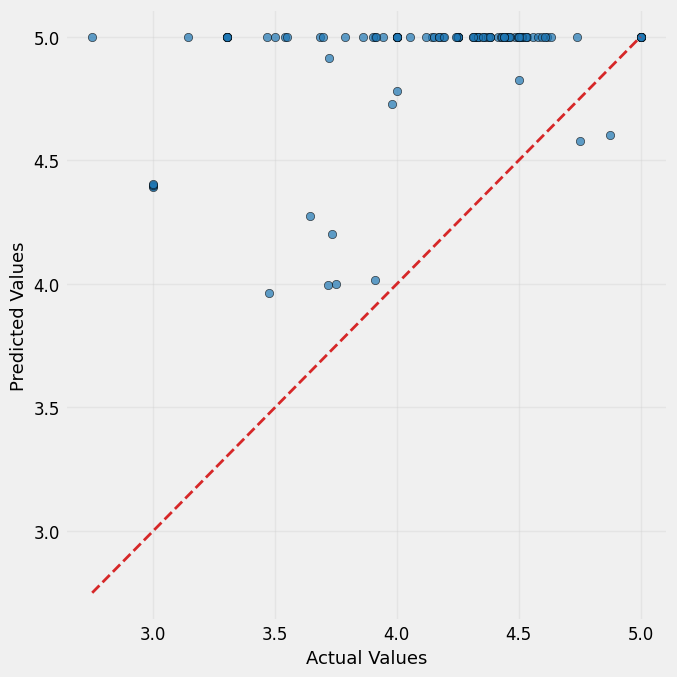

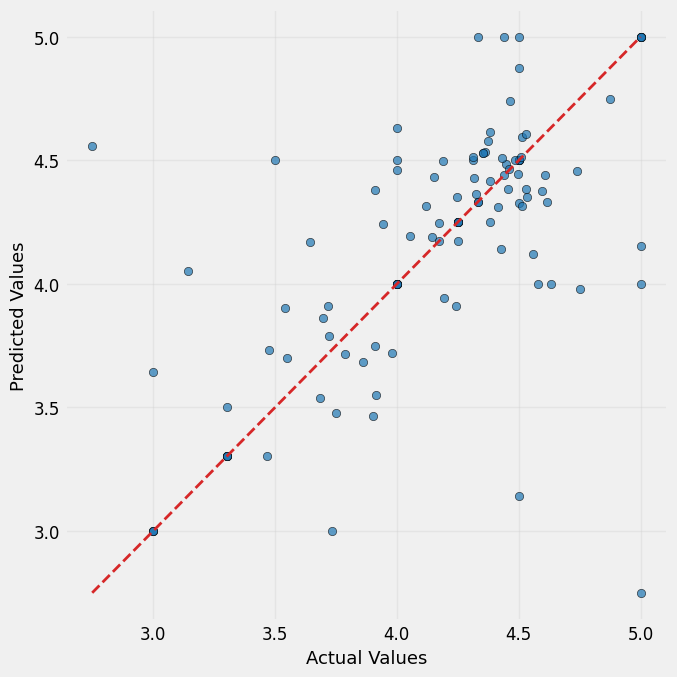

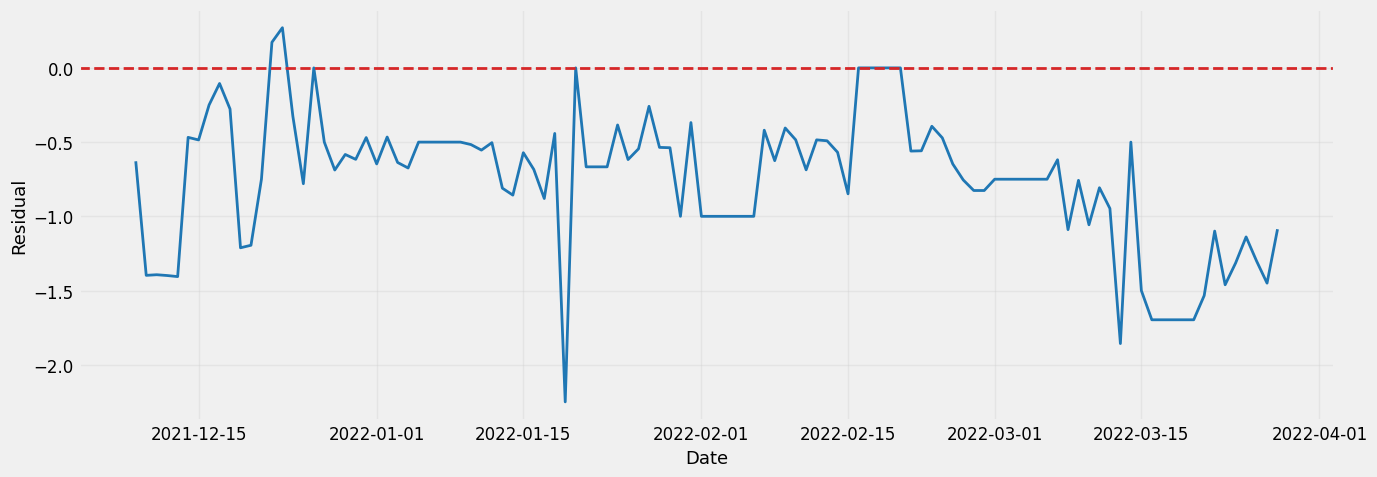

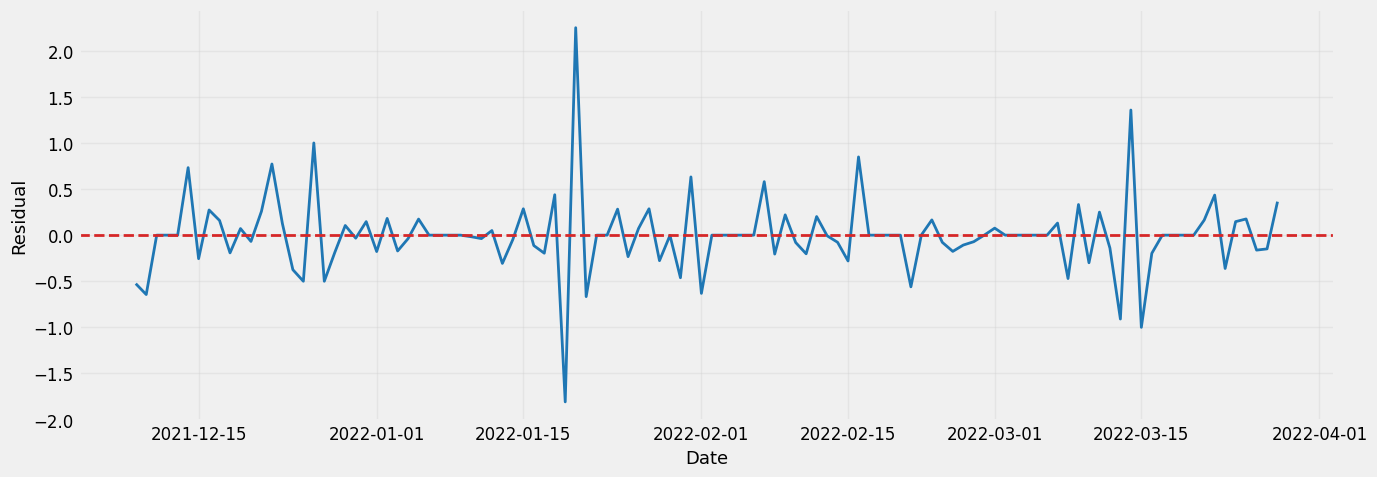

In [13]:
# Run model for mask wearing
mask_model, mask_accuracy, mask_persistence_accuracy, mask_history = run_lstm_pipeline(
    dataset_1,
    target_1
)

Dataset loaded successfully
Daily LSTM dataset shape: (715, 45)
Target variable: wash_hands
Number of exogenous variables: 44
Outcome-specific LSTM settings
{'sequence_length': 7, 'units': 16, 'dropout': 0.2, 'batch_size': 8, 'learning_rate': 0.0005}
Chronological Split
Sequence length: 7
Historical features: 45
Current-day exogenous features: 44
X_sequence_train shape: (493, 7, 45)
X_sequence_validation shape: (107, 7, 45)
X_sequence_test shape: (108, 7, 45)
Validation training epochs: 19
LSTM Accuracy Results
  Model       MSE      RMSE     MAE      MAPE
0  LSTM  9.001839  3.000307  2.7006  0.604673

Persistence Baseline Accuracy Results
                  Model       MSE      RMSE       MAE      MAPE
0  Persistence Baseline  0.144669  0.380354  0.207511  0.048411


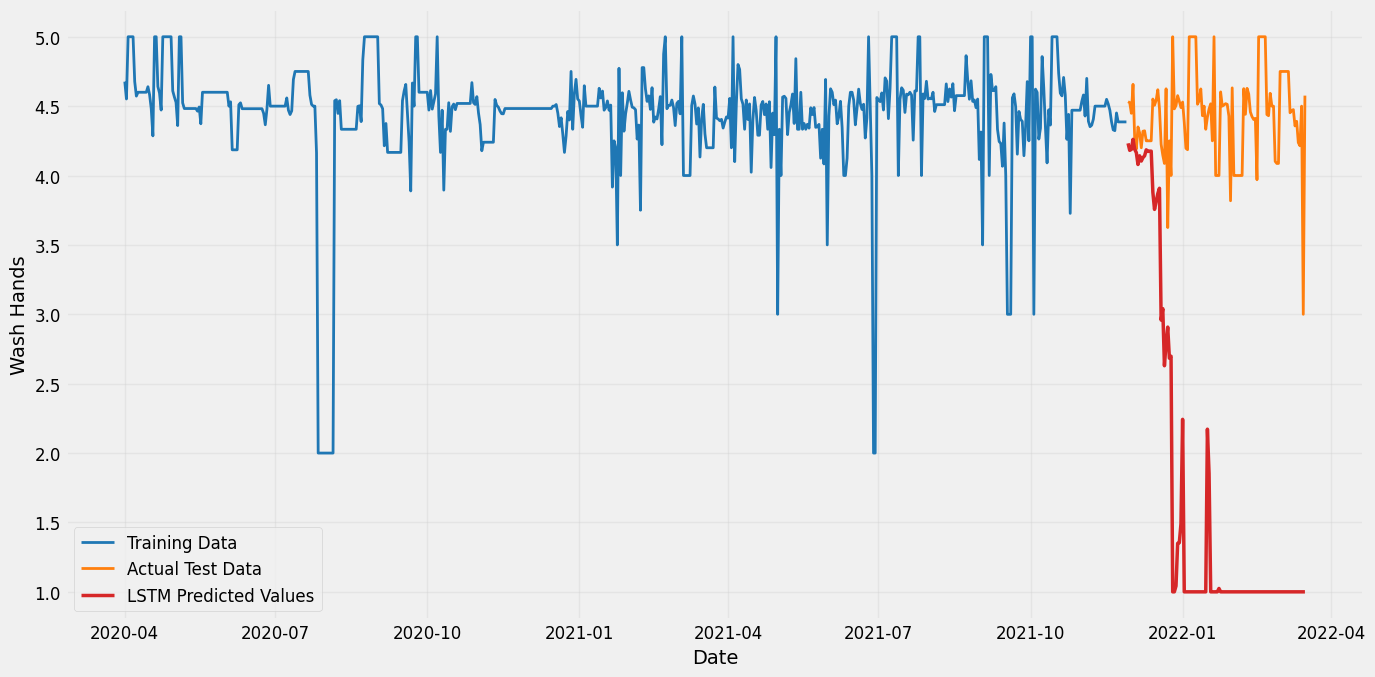

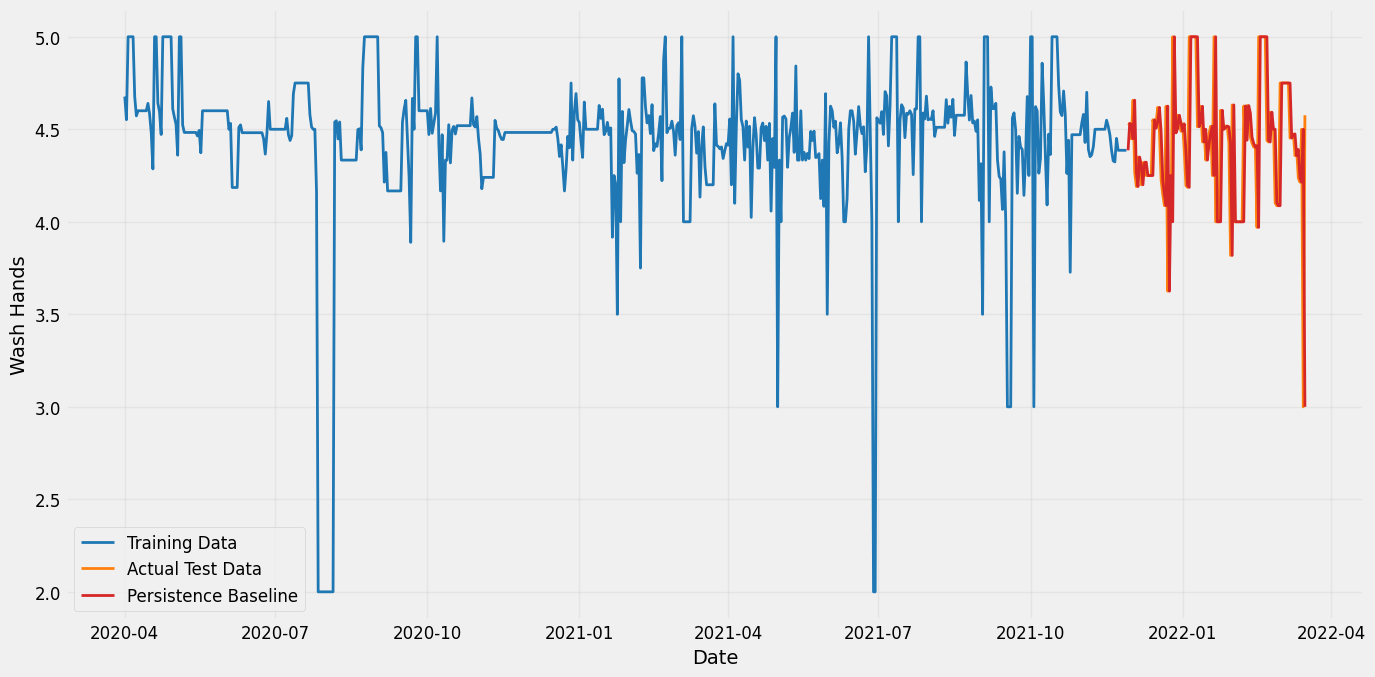

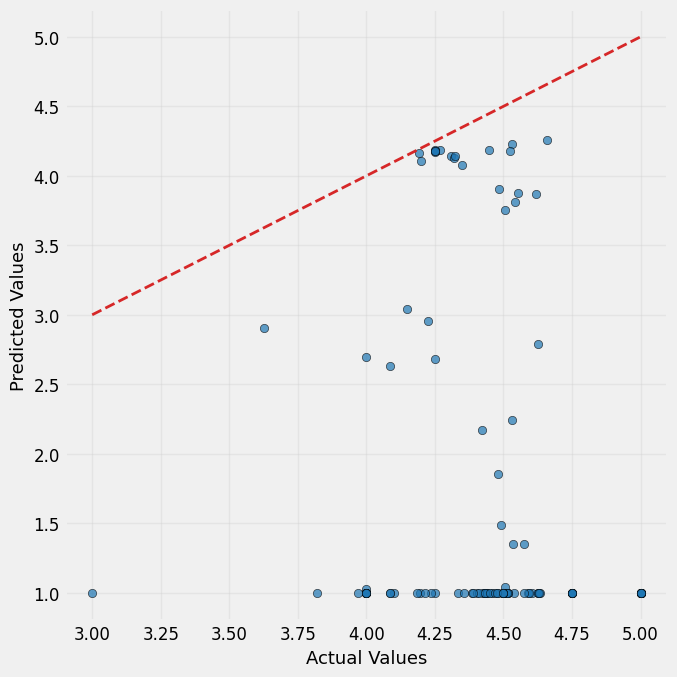

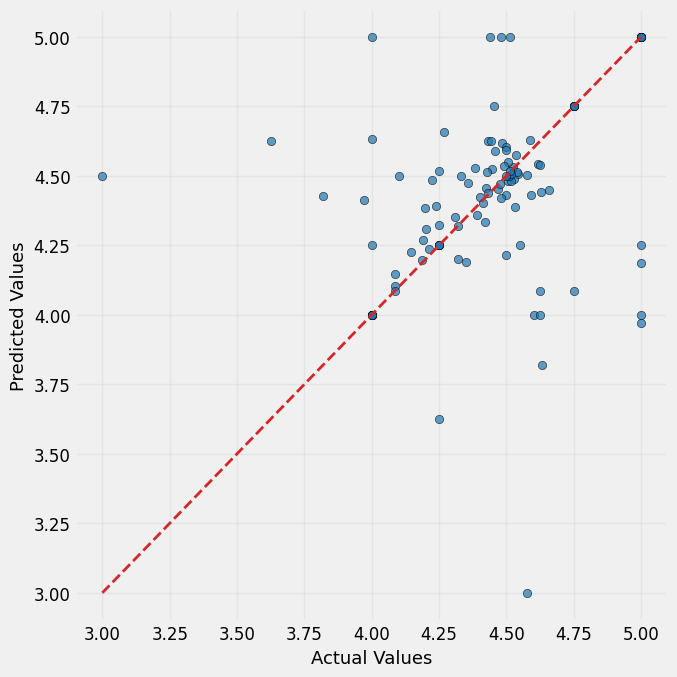

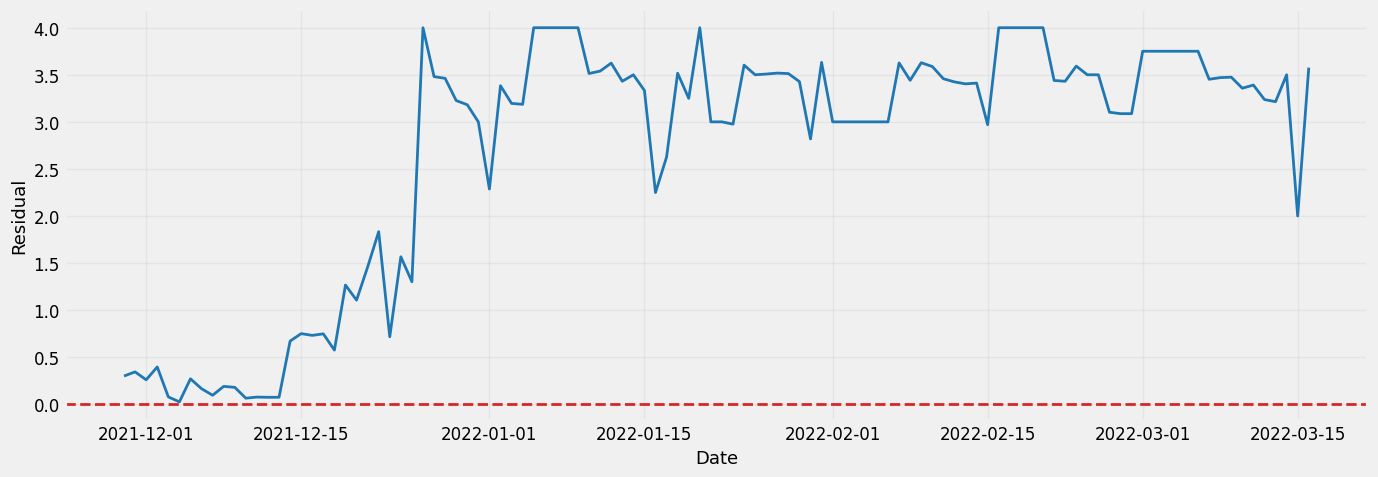

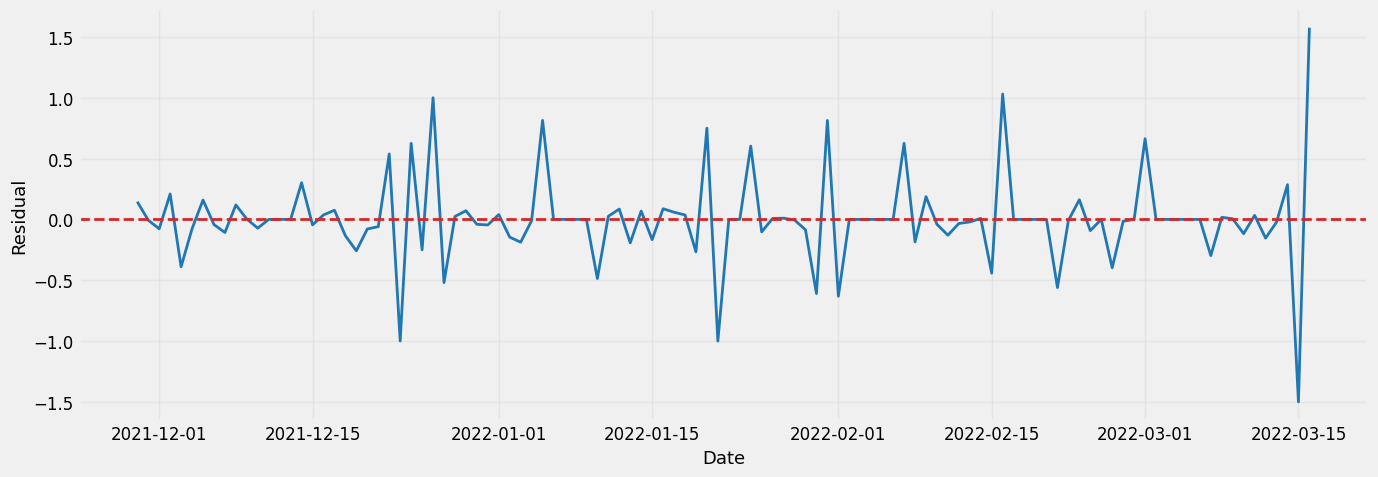

In [14]:
# Run model for hand washing
handwashing_model, handwashing_accuracy, handwashing_persistence_accuracy, handwashing_history = run_lstm_pipeline(
    dataset_2,
    target_2
)

Dataset loaded successfully
Daily LSTM dataset shape: (727, 45)
Target variable: avoid_crowded_areas
Number of exogenous variables: 44
Outcome-specific LSTM settings
{'sequence_length': 21, 'units': 32, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005}
Chronological Split
Sequence length: 21
Historical features: 45
Current-day exogenous features: 44
X_sequence_train shape: (487, 21, 45)
X_sequence_validation shape: (109, 21, 45)
X_sequence_test shape: (110, 21, 45)
Validation training epochs: 33
LSTM Accuracy Results
  Model       MSE      RMSE       MAE      MAPE
0  LSTM  6.198398  2.489658  2.341783  0.641308

Persistence Baseline Accuracy Results
                  Model       MSE      RMSE       MAE      MAPE
0  Persistence Baseline  0.233161  0.482867  0.264498  0.074899


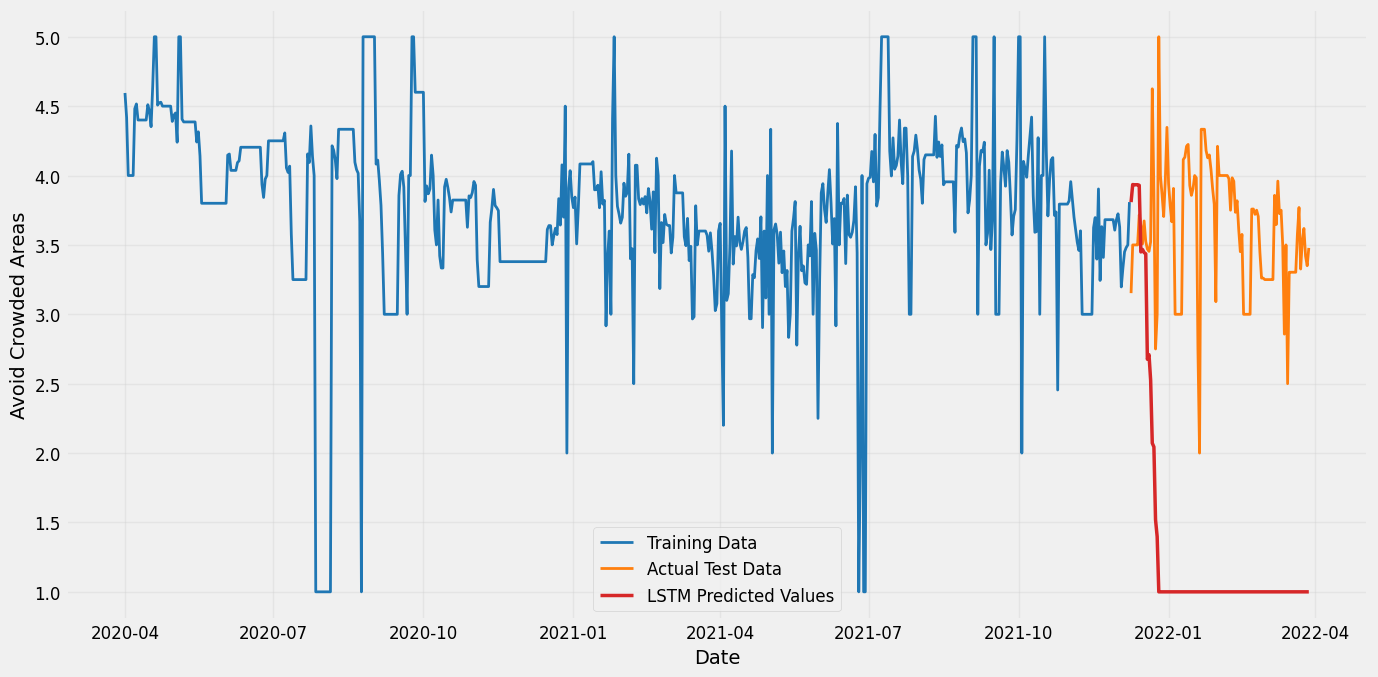

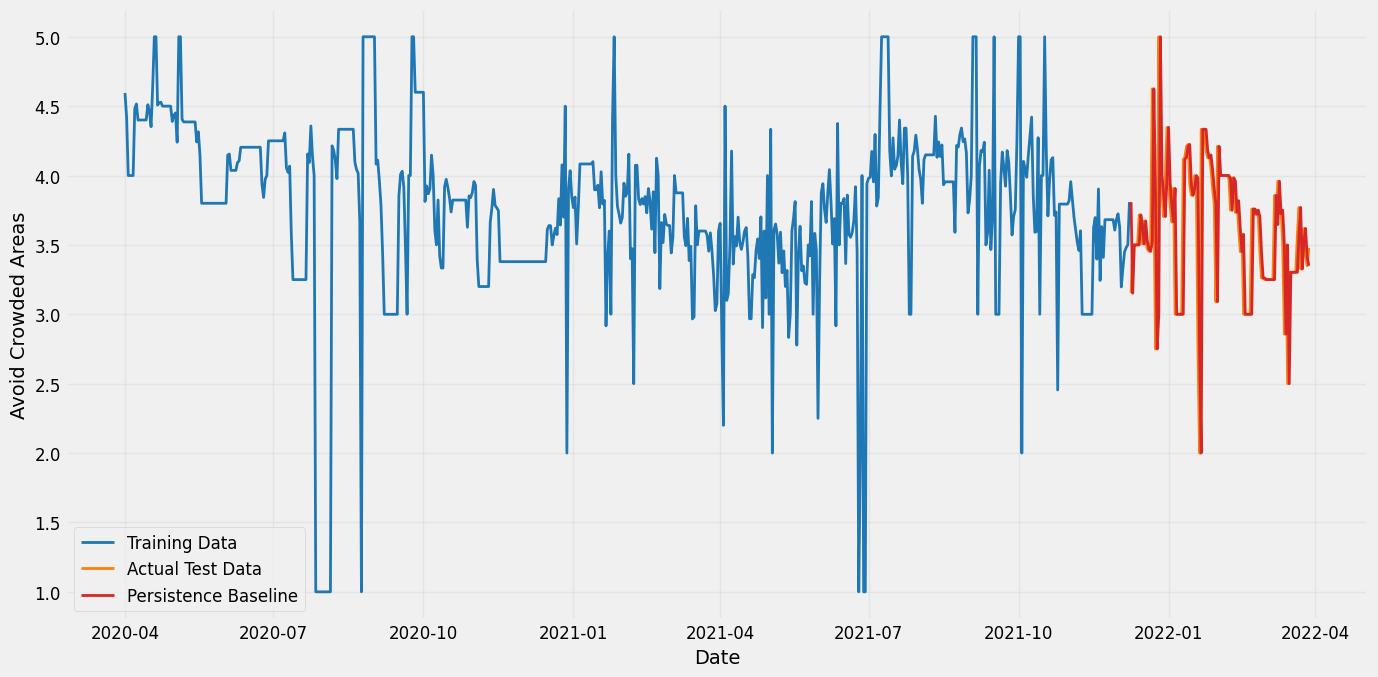

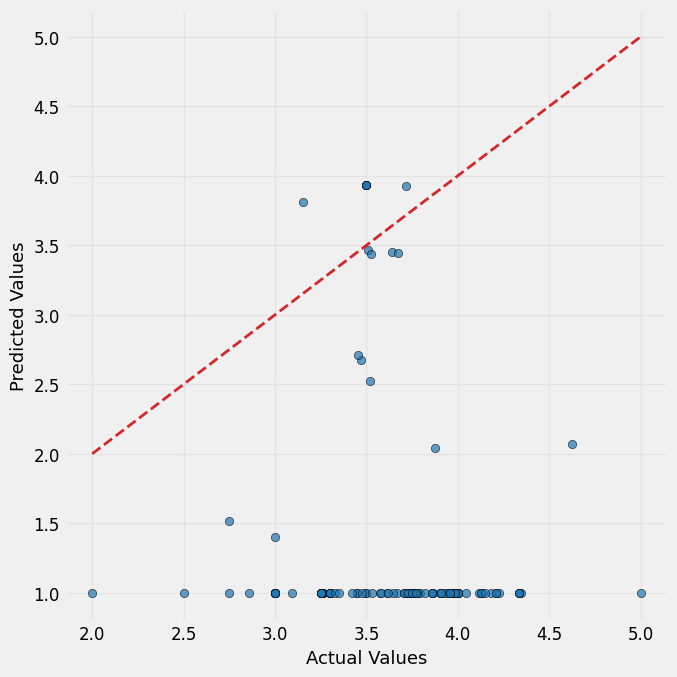

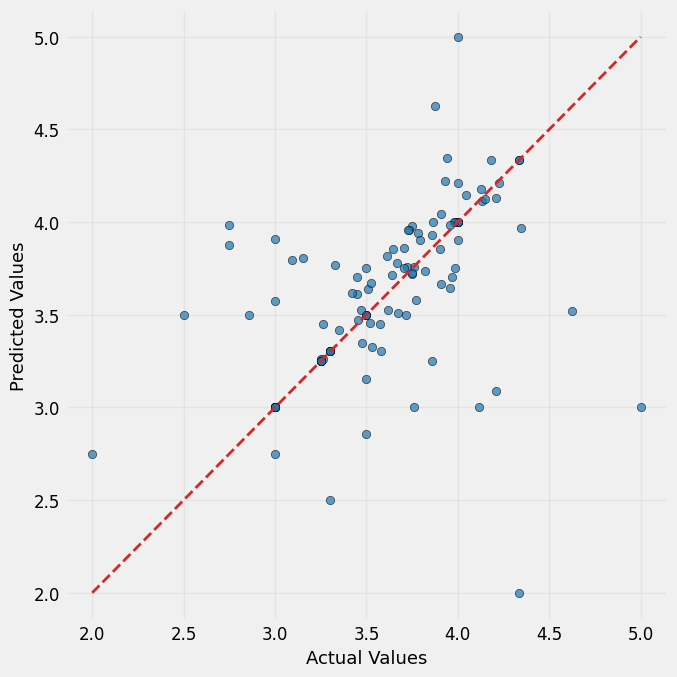

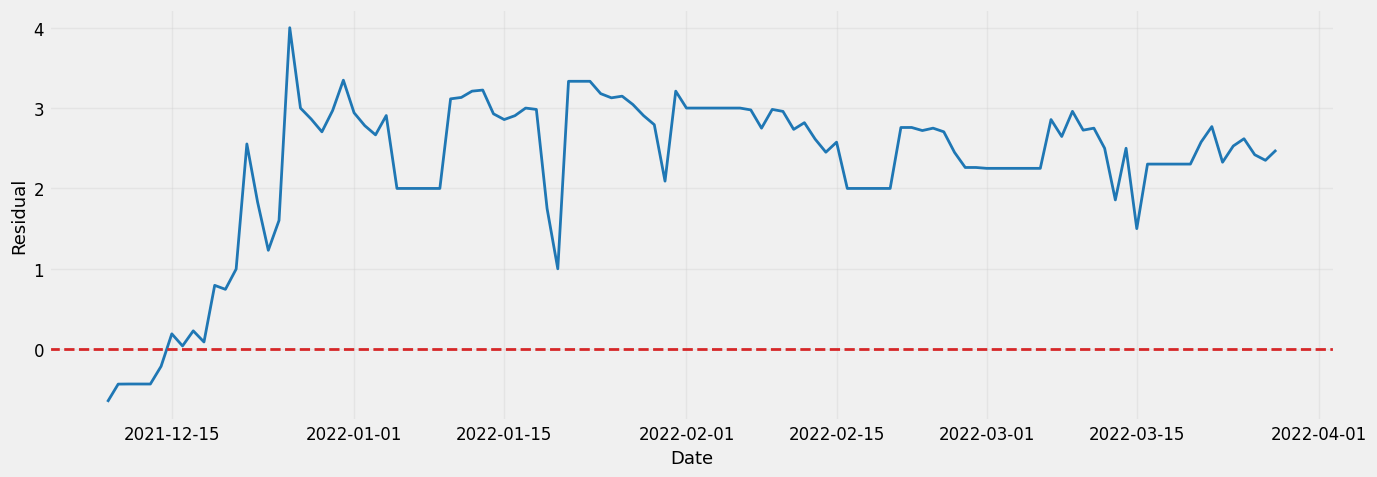

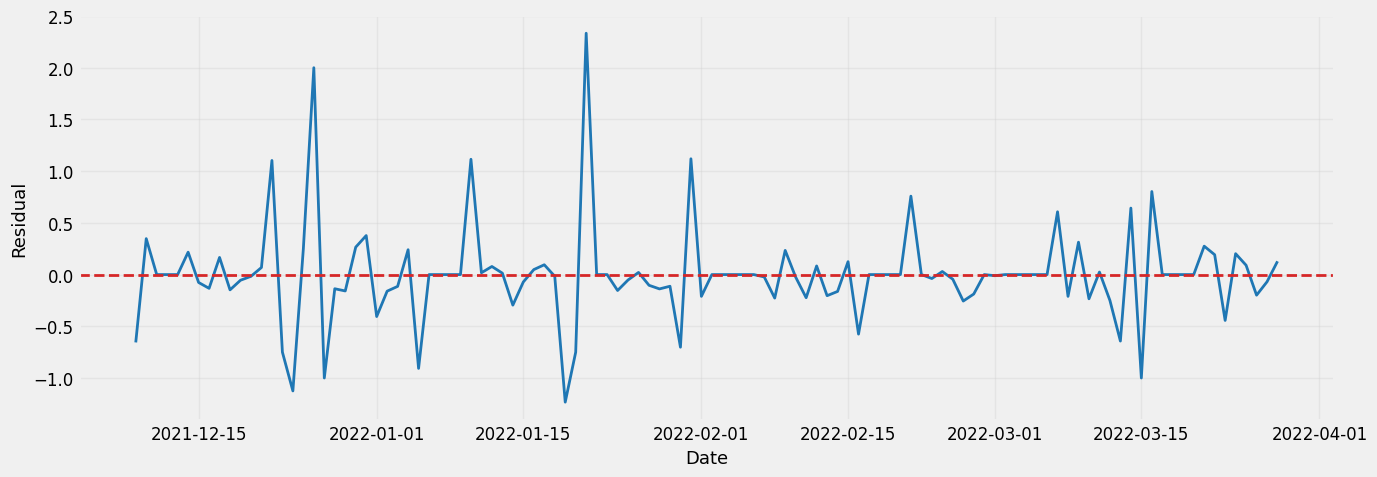

In [15]:
# Run model for Avoid Crowded Areas
crowded_model, crowded_accuracy, crowded_persistence_accuracy, crowded_history = run_lstm_pipeline(
    dataset_3,
    target_3
)

Dataset loaded successfully
Daily LSTM dataset shape: (727, 45)
Target variable: willingness_self_isolate
Number of exogenous variables: 44
Outcome-specific LSTM settings
{'sequence_length': 7, 'units': 16, 'dropout': 0.2, 'batch_size': 8, 'learning_rate': 0.0005}
Chronological Split
Sequence length: 7
Historical features: 45
Current-day exogenous features: 44
X_sequence_train shape: (501, 7, 45)
X_sequence_validation shape: (109, 7, 45)
X_sequence_test shape: (110, 7, 45)
Validation training epochs: 29
LSTM Accuracy Results
  Model       MSE      RMSE       MAE      MAPE
0  LSTM  3.778184  1.943755  1.469397  0.330763

Persistence Baseline Accuracy Results
                  Model       MSE     RMSE       MAE      MAPE
0  Persistence Baseline  0.049337  0.22212  0.141992  0.031852


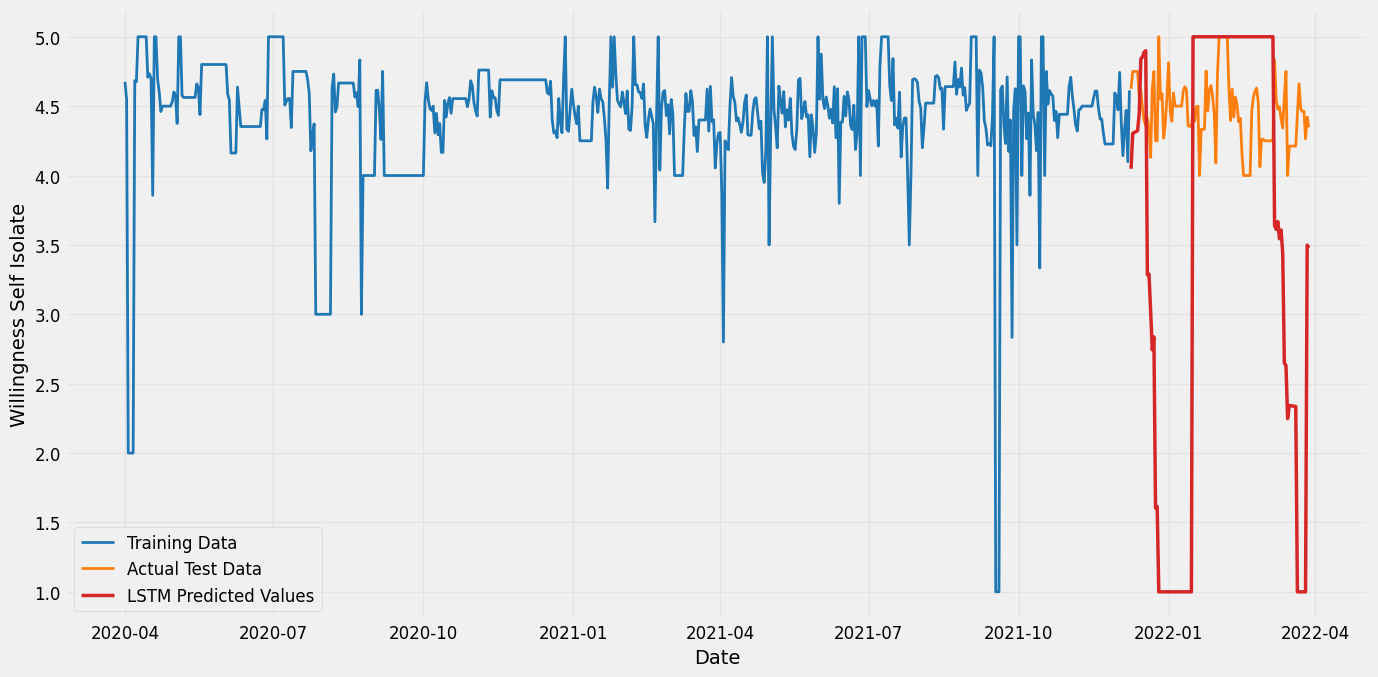

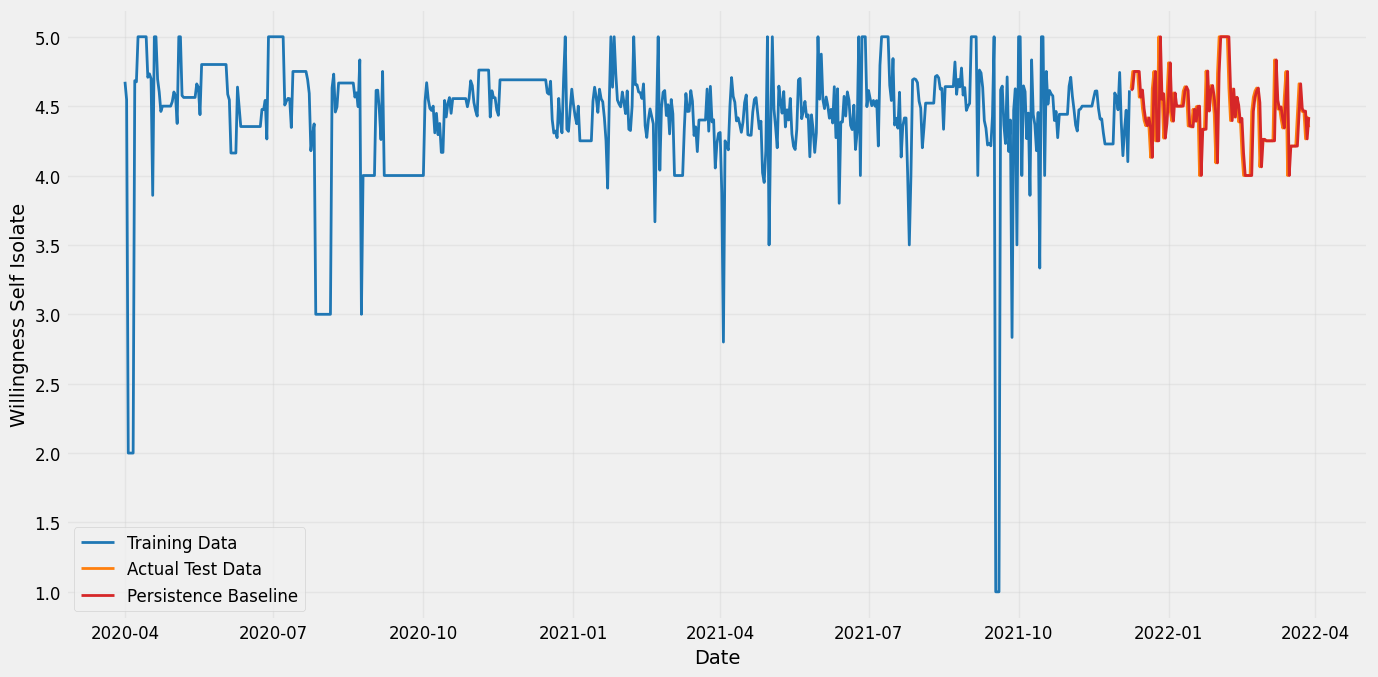

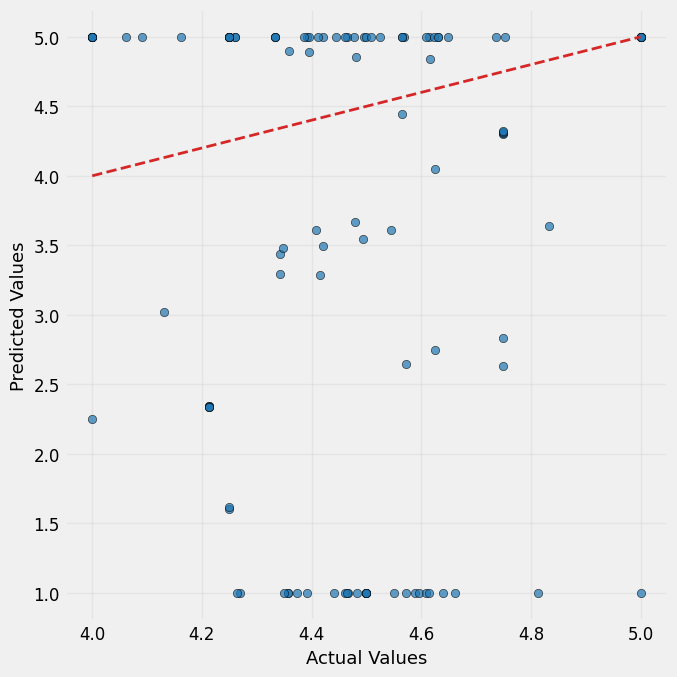

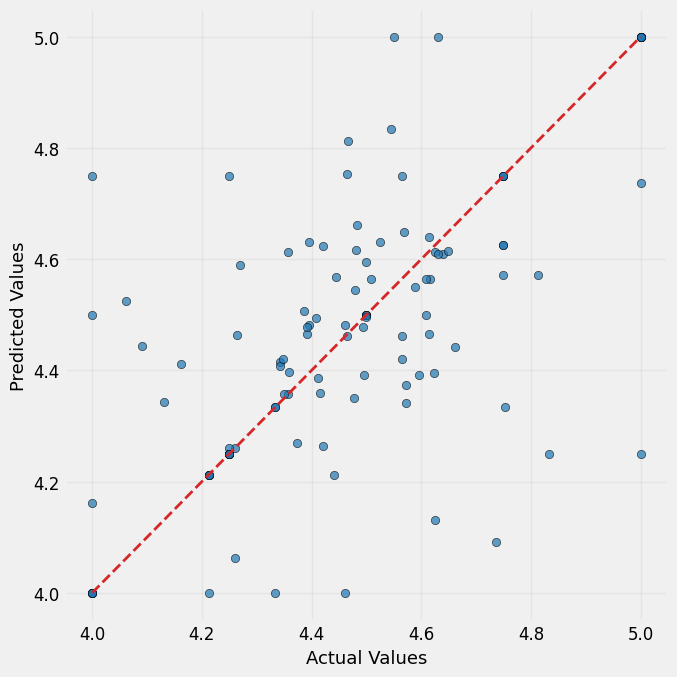

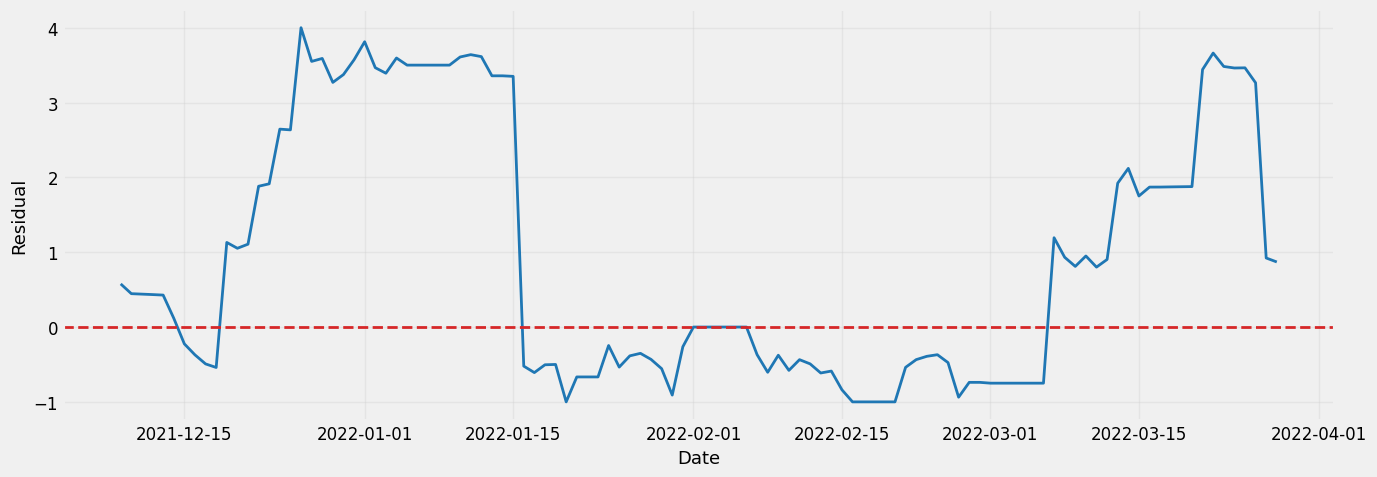

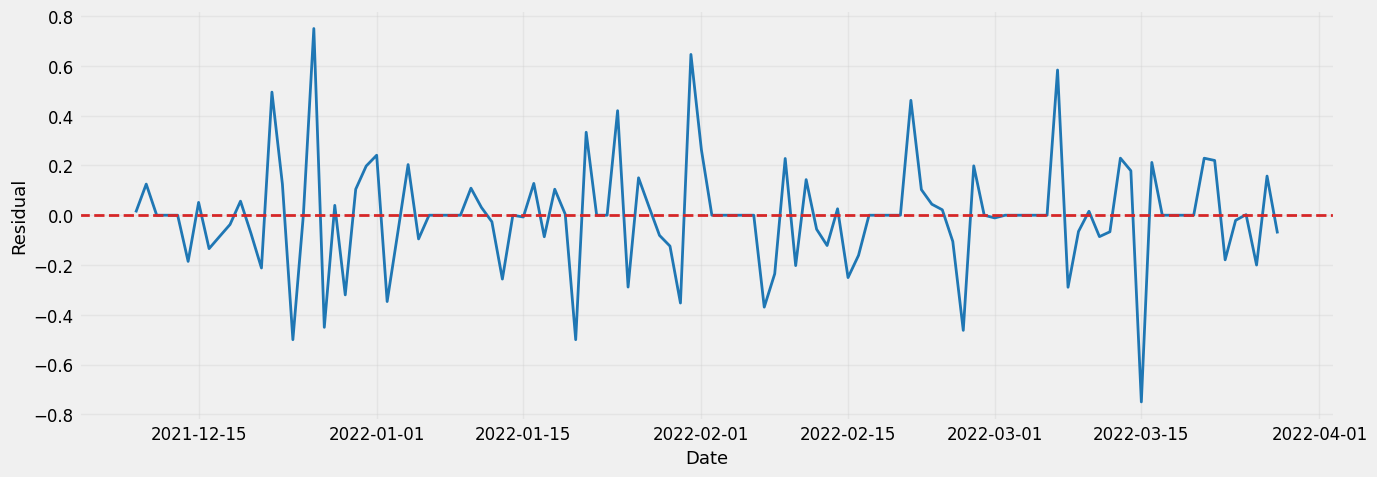

In [16]:
# Run model for self isolation
self_model, self_accuracy, self_persistence_accuracy, self_history = run_lstm_pipeline(
    dataset_4,
    target_4
)

In [17]:
# Combine LSTM results for all 4 outcomes
lstm_results_table = pd.concat(
    [
        mask_accuracy,
        handwashing_accuracy,
        crowded_accuracy,
        self_accuracy
    ],
    ignore_index=True
)

lstm_results_table.insert(
    0,
    "Outcome Variable",
    [
        "Mask Wearing",
        "Hand Washing",
        "Avoid Crowded Areas",
        "Self Isolation"
    ]
)

print("LSTM Results for All Outcomes")
display(lstm_results_table)


# Combine persistence baseline results for all 4 outcomes
persistence_results_table = pd.concat(
    [
        mask_persistence_accuracy,
        handwashing_persistence_accuracy,
        crowded_persistence_accuracy,
        self_persistence_accuracy
    ],
    ignore_index=True
)

persistence_results_table.insert(
    0,
    "Outcome Variable",
    [
        "Mask Wearing",
        "Hand Washing",
        "Avoid Crowded Areas",
        "Self Isolation"
    ]
)

print("Persistence Baseline Results for All Outcomes")
display(persistence_results_table)

LSTM Results for All Outcomes


,Outcome Variable,Model,MSE,RMSE,MAE,MAPE,Sequence Length,LSTM Units,Dropout,Learning Rate,Batch Size
0,Mask Wearing,LSTM,0.773153,0.879291,0.756127,0.197248,30,32,0.3,0.0005,16
1,Hand Washing,LSTM,9.001839,3.000307,2.700600,0.604673,7,16,0.2,0.0005,8
2,Avoid Crowded Areas,LSTM,6.198398,2.489658,2.341783,0.641308,21,32,0.3,0.0005,16
3,Self Isolation,LSTM,3.778184,1.943755,1.469397,0.330763,7,16,0.2,0.0005,8


Persistence Baseline Results for All Outcomes


,Outcome Variable,Model,MSE,RMSE,MAE,MAPE
0,Mask Wearing,Persistence Baseline,0.190834,0.436846,0.252175,0.062469
1,Hand Washing,Persistence Baseline,0.144669,0.380354,0.207511,0.048411
2,Avoid Crowded Areas,Persistence Baseline,0.233161,0.482867,0.264498,0.074899
3,Self Isolation,Persistence Baseline,0.049337,0.222120,0.141992,0.031852
